# ML-модель риска плохого клиентского опыта

## Цель анализа

Негативный отзыв является одним из основных наблюдаемых сигналов плохого клиентского опыта в данных Olist. Цель этого анализа — построить модель, которая оценивает вероятность получения негативного отзыва на основе характеристик заказа, оплаты, доставки и клиента.

Целевая переменная определяется следующим образом:

* `bad_review = 1`, если `review_score <= 3`;
* `bad_review = 0`, если `review_score >= 4`.

Модель рассматривается не как полностью автоматизированное решение, а как инструмент приоритизации: заказы с высоким прогнозируемым риском могут быть направлены на дополнительный анализ или проактивную клиентскую поддержку.

## Момент прогнозирования

В текущей версии модель оценивает риск негативного отзыва **после завершения доставки, но до анализа самого отзыва**. Поэтому допускается использование фактических характеристик доставки:

* продолжительность доставки;
* задержка относительно обещанной даты;
* факт опоздания.

Такой сценарий позволяет выявлять основные факторы плохого клиентского опыта и находить проблемные заказы, категории и операционные процессы.

Развитие проекта может включать отдельную модель, которая прогнозирует риск уже в момент оформления заказа, используя только признаки, известные на момент покупки.


In [1]:
import pandas as pd
import numpy as np

In [2]:
orders_base = pd.read_csv(
    "../data/processed/orders_base.csv",
    parse_dates=[
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date",
    ],
)

orders_base.shape

(99441, 33)

In [3]:
ml_data = orders_base.loc[
    (orders_base["is_delivered"] == 1)
    & (orders_base["has_review"] == 1)
    & (orders_base["review_score"].notna())
].copy()

ml_data["bad_review"] = (ml_data["review_score"] <= 3).astype("int8")

ml_data[["review_score", "bad_review"]].value_counts().sort_index()

review_score  bad_review
1.000000      1              9313
1.500000      1                 8
2.000000      1              2916
2.500000      1                30
3.000000      1              7915
3.333333      0                 1
3.500000      0                23
4.000000      0             18868
4.333333      0                 1
4.500000      0                53
5.000000      0             56704
Name: count, dtype: int64

In [4]:
target_summary = pd.DataFrame({
    "orders": ml_data["bad_review"].value_counts().sort_index(),
    "share": ml_data["bad_review"]
        .value_counts(normalize=True)
        .sort_index()
        .round(4),
})

print("Размер ML-выборки:", ml_data.shape)
print("Уникальных заказов:", ml_data["order_id"].nunique())
print("Дубликатов order_id:", ml_data["order_id"].duplicated().sum())

target_summary

Размер ML-выборки: (95832, 34)
Уникальных заказов: 95832
Дубликатов order_id: 0


,orders,share
bad_review,,
0,75650,0.7894
1,20182,0.2106


## Формирование целевой переменной

Единицей наблюдения является один доставленный заказ, для которого доступна оценка клиента.

После фильтрации выборка содержит 95 832 заказа:

* 75 650 заказов, или 78,94%, получили положительную оценку;
* 20 182 заказа, или 21,06%, получили негативную оценку.

Дубликаты `order_id` отсутствуют, поэтому каждый заказ представлен в выборке ровно одной строкой.

Целевая переменная имеет умеренный дисбаланс классов. Наивная модель, всегда предсказывающая отсутствие негативного отзыва, получила бы accuracy 78,94%. Поэтому accuracy недостаточно для оценки качества модели.

Основными метриками далее будут:

* ROC-AUC — способность модели ранжировать заказы по риску;
* PR-AUC — качество выделения негативного класса при дисбалансе;
* recall и precision — полнота и точность выявления проблемных заказов;
* F1-score — баланс precision и recall;
* lift@10% — концентрация негативных отзывов среди 10% заказов с максимальным прогнозируемым риском.

В редких случаях один заказ имел несколько отзывов, поэтому агрегированный `review_score` может принимать дробные значения. Таких наблюдений мало, однако это ограничение необходимо учитывать при интерпретации целевой переменной.


In [5]:
feature_audit = pd.DataFrame({
    "dtype": ml_data.dtypes.astype(str),
    "missing_count": ml_data.isna().sum(),
    "missing_share": ml_data.isna().mean().round(4),
    "unique_values": ml_data.nunique(dropna=False),
}).sort_values(
    ["missing_share", "unique_values"],
    ascending=[False, False],
)

feature_audit

,dtype,missing_count,missing_share,unique_values
order_delivered_customer_date,datetime64[us],8,0.0001,95017
order_approved_at,datetime64[us],14,0.0001,87727
delivery_delay_days,float64,8,0.0001,197
delivery_days,float64,8,0.0001,144
order_id,str,0,0.0000,95832
customer_id,str,0,0.0000,95832
order_purchase_timestamp,datetime64[us],0,0.0000,95317
last_review_answer_timestamp,str,0,0.0000,95184
customer_unique_id,str,0,0.0000,92755
order_delivered_carrier_date,datetime64[us],2,0.0000,79605


## Аудит признаков и предотвращение утечки данных

Перед построением модели признаки были разделены на допустимые характеристики заказа и колонки, которые могут привести к утечке целевой переменной.

Из модели исключены:

* `review_score`, поскольку на его основе сформирована целевая переменная;
* даты создания и ответа на отзыв;
* количество записей с отзывами;
* флаг наличия отзыва.

Эти данные возникают только после того, как клиент оставил оценку, поэтому их использование привело бы к искусственно завышенному качеству модели.

Также исключены технические идентификаторы заказов и клиентов. Они не имеют самостоятельного бизнес-смысла и могут привести к переобучению модели на отдельных объектах.

Колонки `order_status`, `is_delivered`, `has_review` и `has_items` не используются, поскольку после формирования выборки они являются константами или почти константами.

Фактическая продолжительность доставки и задержка относительно обещанной даты допускаются, поскольку текущая версия модели оценивает риск негативного отзыва после завершения доставки. Для модели, работающей в момент оформления заказа, такие признаки использовать было бы нельзя.


In [6]:
ml_data["purchase_month"] = (
    ml_data["order_purchase_timestamp"].dt.month.astype("int8")
)

ml_data["purchase_dayofweek"] = (
    ml_data["order_purchase_timestamp"].dt.dayofweek.astype("int8")
)

ml_data["purchase_hour"] = (
    ml_data["order_purchase_timestamp"].dt.hour.astype("int8")
)

ml_data["approval_time_hours"] = (
    ml_data["order_approved_at"] - ml_data["order_purchase_timestamp"]
).dt.total_seconds() / 3600

ml_data["estimated_delivery_days"] = (
    ml_data["order_estimated_delivery_date"]
    - ml_data["order_purchase_timestamp"]
).dt.total_seconds() / 86400

ml_data["is_late"] = (
    ml_data["delivery_delay_days"] > 0
).astype("int8")

ml_data["freight_share"] = np.where(
    ml_data["order_value_with_freight"] > 0,
    ml_data["freight_value"] / ml_data["order_value_with_freight"],
    0,
)

In [7]:
derived_features = [
    "purchase_month",
    "purchase_dayofweek",
    "purchase_hour",
    "approval_time_hours",
    "estimated_delivery_days",
    "delivery_days",
    "delivery_delay_days",
    "is_late",
    "freight_share",
]

ml_data[derived_features].describe().T

,count,mean,std,min,25%,50%,75%,max
purchase_month,95832.0,6.031148,3.226717,1.000000,3.000000,6.000000,8.000000,12.000000
purchase_dayofweek,95832.0,2.757367,1.966946,0.000000,1.000000,3.000000,4.000000,6.000000
purchase_hour,95832.0,14.774178,5.325269,0.000000,11.000000,15.000000,19.000000,23.000000
approval_time_hours,95818.0,10.275564,20.537604,0.000000,0.215278,0.343333,14.514861,741.443611
estimated_delivery_days,95832.0,23.731983,8.758686,2.008009,18.327205,23.229155,28.404852,155.135463
delivery_days,95824.0,12.052273,9.466046,0.000000,6.000000,10.000000,15.000000,208.000000
delivery_delay_days,95824.0,-11.913070,10.111737,-147.000000,-17.000000,-12.000000,-7.000000,188.000000
is_late,95832.0,0.066585,0.249304,0.000000,0.000000,0.000000,0.000000,1.000000
freight_share,95832.0,0.208989,0.125568,0.000000,0.116630,0.183256,0.275641,0.955451


In [8]:
ml_data["delivery_metrics_missing"] = (
    ml_data["delivery_delay_days"].isna()
).astype("int8")

ml_data["is_late"] = np.where(
    ml_data["delivery_delay_days"].isna(),
    np.nan,
    (ml_data["delivery_delay_days"] > 0).astype("int8"),
)

ml_data[
    [
        "delivery_days",
        "delivery_delay_days",
        "is_late",
        "delivery_metrics_missing",
    ]
].isna().sum()

delivery_days               8
delivery_delay_days         8
is_late                     8
delivery_metrics_missing    0
dtype: int64

## Производные признаки заказа и доставки

На основе исходных временных и финансовых полей были созданы дополнительные признаки:

* месяц, день недели и час оформления заказа;
* время от оформления до подтверждения оплаты;
* ожидаемый срок доставки;
* фактическая продолжительность доставки;
* отклонение фактической даты доставки от обещанной;
* флаг просроченной доставки;
* доля стоимости доставки в общей стоимости заказа.

Фактическая доставка в среднем занимала около 12 дней, при этом медианный заказ доставлялся примерно на 12 дней раньше обещанного срока. Около 6,7% доставленных заказов были доставлены позже ожидаемой даты.

В данных присутствуют редкие экстремальные значения продолжительности доставки и задержки. Они не удаляются автоматически, поскольку могут отражать реальные операционные сбои и быть особенно важны для выявления риска негативного клиентского опыта.

Для небольшого числа заказов отсутствуют фактические доставочные показатели. Такие наблюдения сохраняются, а отсутствие данных отмечается отдельным признаком.


In [9]:
print(
    "Минимальная дата:",
    ml_data["order_purchase_timestamp"].min(),
)

print(
    "Максимальная дата:",
    ml_data["order_purchase_timestamp"].max(),
)

monthly_target = (
    ml_data
    .assign(
        purchase_period=ml_data["order_purchase_timestamp"]
        .dt.to_period("M")
        .astype(str)
    )
    .groupby("purchase_period")
    .agg(
        orders=("order_id", "size"),
        bad_reviews=("bad_review", "sum"),
        bad_review_rate=("bad_review", "mean"),
    )
)

monthly_target.tail(10)

Минимальная дата: 2016-09-15 12:16:38
Максимальная дата: 2018-08-29 15:00:37


,orders,bad_reviews,bad_review_rate
purchase_period,,,
2017-11,7238,1873,0.258773
2017-12,5461,1242,0.227431
2018-01,7013,1611,0.229716
2018-02,6507,1875,0.288151
2018-03,6948,2106,0.303109
2018-04,6752,1304,0.193128
2018-05,6722,1266,0.188337
2018-06,6075,1015,0.167078
2018-07,6121,1012,0.165332


In [10]:
split_date = pd.Timestamp("2018-06-01")

train_data = ml_data.loc[
    ml_data["order_purchase_timestamp"] < split_date
].copy()

test_data = ml_data.loc[
    ml_data["order_purchase_timestamp"] >= split_date
].copy()

split_summary = pd.DataFrame(
    {
        "orders": [
            len(train_data),
            len(test_data),
        ],
        "bad_reviews": [
            train_data["bad_review"].sum(),
            test_data["bad_review"].sum(),
        ],
        "bad_review_rate": [
            train_data["bad_review"].mean(),
            test_data["bad_review"].mean(),
        ],
        "min_date": [
            train_data["order_purchase_timestamp"].min(),
            test_data["order_purchase_timestamp"].min(),
        ],
        "max_date": [
            train_data["order_purchase_timestamp"].max(),
            test_data["order_purchase_timestamp"].max(),
        ],
    },
    index=["train", "test"],
)

split_summary

,orders,bad_reviews,bad_review_rate,min_date,max_date
train,77306,17110,0.221328,2016-09-15 12:16:38,2018-05-31 23:51:24
test,18526,3072,0.165821,2018-06-01 00:39:55,2018-08-29 15:00:37


## Временное разделение выборки

Для оценки качества модели используется временное, а не случайное разделение данных.

Модель обучается на заказах, оформленных до 1 июня 2018 года, и проверяется на заказах за июнь–август 2018 года. Такой подход имитирует реальный бизнес-сценарий, в котором модель обучается на исторических данных и применяется к будущим заказам.

В тестовом периоде доля негативных отзывов ниже, чем в обучающем. Это указывает на временное изменение клиентского опыта или операционных процессов. Поэтому тестовая выборка проверяет не только способность модели классифицировать заказы, но и её устойчивость к изменению распределения данных.

Случайное разделение могло бы смешать периоды с разным уровнем негативных отзывов и дать чрезмерно оптимистичную оценку качества.


## Временное разделение выборки

Для проверки модели используется временное, а не случайное разделение данных:

* обучающая выборка: заказы до 1 июня 2018 года;
* тестовая выборка: заказы с 1 июня по 29 августа 2018 года.

В обучающую выборку вошло 77 306 заказов, а в тестовую — 18 526 заказов, или около 19,3% всей ML-выборки.

Доля негативных отзывов различается между периодами:

* train — 22,13%;
* test — 16,58%.

Это указывает на временное изменение распределения целевой переменной. Вероятно, в последние месяцы наблюдения изменились качество доставки, структура заказов или другие операционные факторы.

Такое разделение сложнее случайного, но лучше соответствует реальному сценарию: модель обучается на прошлом и применяется к будущим заказам. Поэтому итоговые метрики будут отражать не только качество классификации, но и устойчивость модели к temporal drift.


In [11]:
payments = pd.read_csv(
    "../data/raw/olist_order_payments_dataset.csv"
)

payment_type_agg = (
    payments
    .groupby(
        ["order_id", "payment_type"],
        as_index=False
    )
    .agg(
        payment_type_value=("payment_value", "sum")
    )
)

dominant_payment_type = (
    payment_type_agg
    .sort_values(
        ["order_id", "payment_type_value"],
        ascending=[True, False]
    )
    .drop_duplicates("order_id")
    [["order_id", "payment_type"]]
    .rename(
        columns={"payment_type": "dominant_payment_type"}
    )
)

dominant_payment_type.head()

,order_id,dominant_payment_type
0,00010242fe8c5a6d1ba2dd792cb16214,credit_card
1,00018f77f2f0320c557190d7a144bdd3,credit_card
2,000229ec398224ef6ca0657da4fc703e,credit_card
3,00024acbcdf0a6daa1e931b038114c75,credit_card
4,00042b26cf59d7ce69dfabb4e55b4fd9,credit_card


In [12]:
ml_data = ml_data.merge(
    dominant_payment_type,
    on="order_id",
    how="left",
    validate="one_to_one",
)

print(
    "Пропусков dominant_payment_type:",
    ml_data["dominant_payment_type"].isna().sum()
)

ml_data["dominant_payment_type"].value_counts(
    dropna=False
)

Пропусков dominant_payment_type: 1


dominant_payment_type
credit_card    72298
boleto         19062
voucher         2993
debit_card      1478
NaN                1
Name: count, dtype: int64

In [13]:
ml_data["dominant_payment_type"] = (
    ml_data["dominant_payment_type"].fillna("unknown")
)

ml_data["dominant_payment_type"].value_counts(dropna=False)

dominant_payment_type
credit_card    72298
boleto         19062
voucher         2993
debit_card      1478
unknown            1
Name: count, dtype: int64

## Основной тип оплаты

Для каждого заказа определён основной тип оплаты — способ платежа, на который приходится наибольшая суммарная сумма платежей по заказу.

Большинство заказов оплачено кредитной картой. Далее следуют `boleto`, ваучеры и дебетовые карты.

Для одного заказа отсутствовала связанная платежная запись. Это соответствует аномалии, обнаруженной при проверке качества данных в День 1. Заказ сохранён в выборке, а тип оплаты обозначен как `unknown`.

Тип оплаты не является утечкой данных: эта информация формируется до доставки и до появления клиентского отзыва.


In [14]:
split_date = pd.Timestamp("2018-06-01")

train_data = ml_data.loc[
    ml_data["order_purchase_timestamp"] < split_date
].copy()

test_data = ml_data.loc[
    ml_data["order_purchase_timestamp"] >= split_date
].copy()

In [15]:
numeric_features = [
    "order_value_with_freight",
    "freight_share",
    "payment_installments",
    "payment_records_count",
    "payment_types_count",
    "items_count",
    "products_count",
    "sellers_count",
    "approval_time_hours",
    "estimated_delivery_days",
    "delivery_days",
    "delivery_delay_days",
    "is_late",
    "delivery_metrics_missing",
]

categorical_features = [
    "customer_state",
    "dominant_payment_type",
    "purchase_month",
    "purchase_dayofweek",
    "purchase_hour",
]

feature_columns = numeric_features + categorical_features

X_train = train_data[feature_columns].copy()
X_test = test_data[feature_columns].copy()

y_train = train_data["bad_review"].copy()
y_test = test_data["bad_review"].copy()

In [16]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

print("\nПропуски в train:")
display(
    X_train.isna()
    .sum()
    .loc[lambda x: x > 0]
    .sort_values(ascending=False)
)

print("\nПропуски в test:")
display(
    X_test.isna()
    .sum()
    .loc[lambda x: x > 0]
    .sort_values(ascending=False)
)

X_train: (77306, 19)
X_test: (18526, 19)
y_train: (77306,)
y_test: (18526,)

Пропуски в train:


approval_time_hours    14
delivery_days           2
delivery_delay_days     2
is_late                 2
dtype: int64


Пропуски в test:


delivery_days          6
delivery_delay_days    6
is_late                6
dtype: int64

In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

In [18]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_features),
        ("categorical", categorical_transformer, categorical_features),
    ]
)

In [19]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42,
            ),
        ),
    ]
)

logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int8](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['order_value_with_freight','freight_share','payment_installments',..., 'purchase_month','purchase_dayofweek','purchase_hour']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. 

In [20]:
def calculate_metrics(model, X, y, threshold=0.5):
    probabilities = model.predict_proba(X)[:, 1]
    predictions = (probabilities >= threshold).astype(int)

    top_10_count = max(1, int(len(y) * 0.10))
    top_10_indices = np.argsort(probabilities)[-top_10_count:]

    top_10_bad_review_rate = y.iloc[top_10_indices].mean()
    base_bad_review_rate = y.mean()

    return {
        "roc_auc": roc_auc_score(y, probabilities),
        "pr_auc": average_precision_score(y, probabilities),
        "accuracy": accuracy_score(y, predictions),
        "precision": precision_score(y, predictions, zero_division=0),
        "recall": recall_score(y, predictions, zero_division=0),
        "f1": f1_score(y, predictions, zero_division=0),
        "lift_at_10": top_10_bad_review_rate / base_bad_review_rate,
    }


logistic_metrics = pd.DataFrame(
    {
        "train": calculate_metrics(
            logistic_model,
            X_train,
            y_train,
        ),
        "test": calculate_metrics(
            logistic_model,
            X_test,
            y_test,
        ),
    }
).T

logistic_metrics.round(4)

,roc_auc,pr_auc,accuracy,precision,recall,f1,lift_at_10
train,0.7097,0.5091,0.8183,0.7252,0.2884,0.4127,3.1142
test,0.6491,0.3439,0.8436,0.6225,0.1439,0.2337,2.6539


In [21]:
test_probabilities = logistic_model.predict_proba(X_test)[:, 1]
test_predictions = (test_probabilities >= 0.5).astype(int)

confusion_matrix(
    y_test,
    test_predictions,
)

array([[15186,   268],
       [ 2630,   442]])

## Результаты Logistic Regression baseline

В качестве интерпретируемой базовой модели была обучена логистическая регрессия.

На тестовом периоде модель получила:

* ROC-AUC — 0,649;
* PR-AUC — 0,344;
* precision — 62,25%;
* recall — 14,39%;
* F1-score — 0,234;
* lift@10% — 2,65.

ROC-AUC показывает, что модель ранжирует заказы по риску лучше случайного классификатора, однако качество остаётся умеренным.

PR-AUC необходимо сравнивать с долей позитивного класса в задаче. Поскольку негативные отзывы составляют 16,58% тестовой выборки, случайный baseline для PR-AUC был бы около 0,166. Полученный результат 0,344 примерно в два раза выше этого уровня.

Lift@10% имеет более прямую бизнес-интерпретацию: среди 10% заказов с наибольшим прогнозируемым риском доля негативных отзывов составляет около 44%, что в 2,65 раза выше среднего уровня тестовой выборки. Это означает, что модель уже может быть полезна для приоритизации ограниченного объёма заказов для проверки или клиентской поддержки.

При стандартном пороге 0,5 модель выявила только 442 из 3 072 негативных заказов. Recall составил 14,39%, поэтому модель пропускает большую часть проблемных случаев. Высокая accuracy частично объясняется преобладанием положительного класса и не должна использоваться как основная метрика.

Разница между train и test указывает на снижение качества на будущем периоде. Возможные причины — temporal drift, изменение доли негативных отзывов и ограниченная способность линейной модели описывать нелинейные зависимости.


In [22]:
validation_start = pd.Timestamp("2018-04-01")
test_start = pd.Timestamp("2018-06-01")

fit_data = ml_data.loc[
    ml_data["order_purchase_timestamp"] < validation_start
].copy()

validation_data = ml_data.loc[
    (ml_data["order_purchase_timestamp"] >= validation_start)
    & (ml_data["order_purchase_timestamp"] < test_start)
].copy()

test_data = ml_data.loc[
    ml_data["order_purchase_timestamp"] >= test_start
].copy()

selection_split_summary = pd.DataFrame(
    {
        "orders": [
            len(fit_data),
            len(validation_data),
            len(test_data),
        ],
        "bad_reviews": [
            fit_data["bad_review"].sum(),
            validation_data["bad_review"].sum(),
            test_data["bad_review"].sum(),
        ],
        "bad_review_rate": [
            fit_data["bad_review"].mean(),
            validation_data["bad_review"].mean(),
            test_data["bad_review"].mean(),
        ],
        "min_date": [
            fit_data["order_purchase_timestamp"].min(),
            validation_data["order_purchase_timestamp"].min(),
            test_data["order_purchase_timestamp"].min(),
        ],
        "max_date": [
            fit_data["order_purchase_timestamp"].max(),
            validation_data["order_purchase_timestamp"].max(),
            test_data["order_purchase_timestamp"].max(),
        ],
    },
    index=["fit", "validation", "test"],
)

selection_split_summary

,orders,bad_reviews,bad_review_rate,min_date,max_date
fit,63832,14540,0.227785,2016-09-15 12:16:38,2018-03-31 23:54:10
validation,13474,2570,0.190738,2018-04-01 00:11:32,2018-05-31 23:51:24
test,18526,3072,0.165821,2018-06-01 00:39:55,2018-08-29 15:00:37


In [23]:
from sklearn.base import clone

X_fit = fit_data[feature_columns].copy()
y_fit = fit_data["bad_review"].copy()

X_validation = validation_data[feature_columns].copy()
y_validation = validation_data["bad_review"].copy()

X_test = test_data[feature_columns].copy()
y_test = test_data["bad_review"].copy()

logistic_fit_model = clone(logistic_model)

logistic_fit_model.fit(
    X_fit,
    y_fit,
)

validation_probabilities = logistic_fit_model.predict_proba(
    X_validation
)[:, 1]

In [24]:
thresholds = np.arange(0.10, 0.51, 0.05)

threshold_results = []

for threshold in thresholds:
    predictions = (
        validation_probabilities >= threshold
    ).astype(int)

    threshold_results.append(
        {
            "threshold": threshold,
            "precision": precision_score(
                y_validation,
                predictions,
                zero_division=0,
            ),
            "recall": recall_score(
                y_validation,
                predictions,
                zero_division=0,
            ),
            "f1": f1_score(
                y_validation,
                predictions,
                zero_division=0,
            ),
            "predicted_positive_share": predictions.mean(),
            "predicted_positive_orders": predictions.sum(),
        }
    )

threshold_results = pd.DataFrame(threshold_results)

threshold_results.round(4)

,threshold,precision,recall,f1,predicted_positive_share,predicted_positive_orders
0,0.10,0.1911,0.9973,0.3208,0.9953,13411
1,0.15,0.2521,0.7268,0.3743,0.5499,7410
2,0.20,0.3730,0.4728,0.4170,0.2417,3257
3,0.25,0.5040,0.3475,0.4113,0.1315,1772
4,0.30,0.5822,0.2949,0.3915,0.0966,1302
5,0.35,0.6190,0.2732,0.3790,0.0842,1134
6,0.40,0.6385,0.2646,0.3741,0.0790,1065
7,0.45,0.6478,0.2584,0.3694,0.0761,1025
8,0.50,0.6535,0.2502,0.3618,0.0730,984


## Выбор порога классификации

Стандартный порог 0,5 оказался слишком консервативным и приводил к низкому recall.

На validation-выборке были сравнены пороги от 0,10 до 0,50.

Максимальный F1-score получен при пороге 0,20:

* precision — 37,30%;
* recall — 47,28%;
* F1-score — 0,417;
* модель классифицирует как рискованные около 24,2% заказов.

Однако такой порог создаёт значительную нагрузку на клиентскую поддержку.

В качестве рабочего бизнес-порога выбран уровень 0,30:

* precision — 58,22%;
* recall — 29,49%;
* F1-score — 0,392;
* в группу риска попадает около 9,7% заказов.

Этот вариант соответствует сценарию ограниченного ресурса поддержки, когда бизнес может дополнительно проверить примерно 10% заказов с наиболее высоким прогнозируемым риском.

Порог 0,20 можно использовать, если приоритетом является более высокий охват негативных случаев, а порог 0,30 — если важнее точность и ограничение операционной нагрузки.


In [25]:
selected_threshold = 0.30

X_train = train_data[feature_columns].copy()
y_train = train_data["bad_review"].copy()

final_logistic_model = clone(logistic_model)

final_logistic_model.fit(
    X_train,
    y_train,
)

test_probabilities = final_logistic_model.predict_proba(
    X_test
)[:, 1]

test_predictions = (
    test_probabilities >= selected_threshold
).astype(int)

In [26]:
final_logistic_metrics = pd.Series(
    {
        "roc_auc": roc_auc_score(
            y_test,
            test_probabilities,
        ),
        "pr_auc": average_precision_score(
            y_test,
            test_probabilities,
        ),
        "accuracy": accuracy_score(
            y_test,
            test_predictions,
        ),
        "precision": precision_score(
            y_test,
            test_predictions,
            zero_division=0,
        ),
        "recall": recall_score(
            y_test,
            test_predictions,
            zero_division=0,
        ),
        "f1": f1_score(
            y_test,
            test_predictions,
            zero_division=0,
        ),
        "predicted_positive_share": (
            test_predictions.mean()
        ),
        "predicted_positive_orders": (
            test_predictions.sum()
        ),
    }
)

final_logistic_metrics.round(4)

roc_auc                         0.6491
pr_auc                          0.3439
accuracy                        0.8373
precision                       0.5242
recall                          0.2044
f1                              0.2941
predicted_positive_share        0.0647
predicted_positive_orders    1198.0000
dtype: float64

In [27]:
confusion_matrix(
    y_test,
    test_predictions,
)

array([[14884,   570],
       [ 2444,   628]])

## Итоговая оценка Logistic Regression

После выбора рабочего порога 0,30 на validation-выборке модель была переобучена на полном обучающем периоде и оценена на независимом тестовом периоде.

Результаты на test:

- ROC-AUC — 0,649;
- PR-AUC — 0,344;
- precision — 52,42%;
- recall — 20,44%;
- F1-score — 0,294;
- доля заказов, направленных в группу риска, — 6,47%.

Модель выявила 628 из 3 072 заказов с негативными отзывами. При этом 570 заказов были ошибочно отнесены к рискованным, а 2 444 негативных случая остались невыявленными.

Снижение порога с 0,50 до 0,30 повысило recall и F1-score, но фактическая доля отмеченных заказов на test оказалась ниже, чем на validation. Это показывает, что из-за временного изменения распределения данных фиксированный порог не гарантирует постоянную нагрузку на поддержку.

В реальном продукте порог необходимо регулярно перекалибровывать либо заменять правилом, при котором бизнес обрабатывает фиксированный процент заказов с наибольшим прогнозируемым риском.

In [28]:
from catboost import CatBoostClassifier

In [29]:
X_fit_cb = fit_data[feature_columns].copy()
X_validation_cb = validation_data[feature_columns].copy()

y_fit_cb = fit_data["bad_review"].copy()
y_validation_cb = validation_data["bad_review"].copy()

for column in categorical_features:
    X_fit_cb[column] = (
        X_fit_cb[column]
        .fillna("unknown")
        .astype(str)
    )

    X_validation_cb[column] = (
        X_validation_cb[column]
        .fillna("unknown")
        .astype(str)
    )

In [30]:
catboost_model = CatBoostClassifier(
    iterations=1000,
    depth=6,
    learning_rate=0.05,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=100,
    allow_writing_files=False,
)

catboost_model.fit(
    X_fit_cb,
    y_fit_cb,
    cat_features=categorical_features,
    eval_set=(X_validation_cb, y_validation_cb),
    use_best_model=True,
    early_stopping_rounds=100,
)

print("Лучшая итерация:", catboost_model.get_best_iteration())
print("Лучший validation AUC:", catboost_model.get_best_score())

0:	test: 0.6430812	best: 0.6430812 (0)	total: 266ms	remaining: 4m 26s
100:	test: 0.6870595	best: 0.6871594 (96)	total: 10.2s	remaining: 1m 30s
200:	test: 0.6898720	best: 0.6898720 (200)	total: 20s	remaining: 1m 19s
300:	test: 0.6889435	best: 0.6900108 (214)	total: 30.5s	remaining: 1m 10s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.690010841
bestIteration = 214

Shrink model to first 215 iterations.
Лучшая итерация: 214
Лучший validation AUC: {'learn': {'Logloss': 0.44658379254948816}, 'validation': {'Logloss': 0.43059837719856714, 'AUC': 0.690010840986494}}


In [31]:
def calculate_ranking_metrics(
    y_true,
    probabilities,
    top_share=0.10,
):
    top_count = max(
        1,
        int(len(y_true) * top_share),
    )

    top_indices = np.argsort(
        probabilities
    )[-top_count:]

    base_bad_review_rate = y_true.mean()

    top_bad_review_rate = (
        y_true.iloc[top_indices].mean()
    )

    return {
        "roc_auc": roc_auc_score(
            y_true,
            probabilities,
        ),
        "pr_auc": average_precision_score(
            y_true,
            probabilities,
        ),
        "base_bad_review_rate": base_bad_review_rate,
        "top_10_bad_review_rate": top_bad_review_rate,
        "lift_at_10": (
            top_bad_review_rate
            / base_bad_review_rate
        ),
    }

In [32]:
catboost_validation_probabilities = (
    catboost_model.predict_proba(
        X_validation_cb
    )[:, 1]
)

In [33]:
validation_model_comparison = pd.DataFrame(
    {
        "Logistic Regression": (
            calculate_ranking_metrics(
                y_validation,
                validation_probabilities,
            )
        ),
        "CatBoost": (
            calculate_ranking_metrics(
                y_validation,
                catboost_validation_probabilities,
            )
        ),
    }
).T

validation_model_comparison.round(4)

,roc_auc,pr_auc,base_bad_review_rate,top_10_bad_review_rate,lift_at_10
Logistic Regression,0.6908,0.4341,0.1907,0.5731,3.0048
CatBoost,0.6900,0.4552,0.1907,0.5768,3.0242


## Сравнение моделей на validation-выборке

Logistic Regression и CatBoost показали близкое качество ранжирования заказов по риску.

Logistic Regression получила немного более высокий ROC-AUC:

- Logistic Regression — 0,691;
- CatBoost — 0,690.

При этом CatBoost показал лучший PR-AUC:

- Logistic Regression — 0,434;
- CatBoost — 0,455.

Для задачи выявления негативных отзывов PR-AUC особенно важен, поскольку он лучше отражает качество работы с миноритарным классом.

Среди 10% заказов с максимальным прогнозируемым риском доля негативных отзывов составила:

- 57,31% для Logistic Regression;
- 57,68% для CatBoost.

Lift@10% составил около 3 для обеих моделей. Следовательно, верхний риск-сегмент содержит примерно в три раза больше негативных отзывов, чем validation-выборка в среднем.

CatBoost показывает небольшое преимущество по PR-AUC, но разница между моделями не является радикальной. Это означает, что значительная часть зависимости может быть описана относительно простой линейной моделью, а добавленная ценность нелинейного алгоритма пока ограничена.

In [34]:
catboost_threshold_results = []

for threshold in thresholds:
    predictions = (
        catboost_validation_probabilities >= threshold
    ).astype(int)

    catboost_threshold_results.append(
        {
            "threshold": threshold,
            "precision": precision_score(
                y_validation,
                predictions,
                zero_division=0,
            ),
            "recall": recall_score(
                y_validation,
                predictions,
                zero_division=0,
            ),
            "f1": f1_score(
                y_validation,
                predictions,
                zero_division=0,
            ),
            "predicted_positive_share": predictions.mean(),
            "predicted_positive_orders": predictions.sum(),
        }
    )

catboost_threshold_results = pd.DataFrame(
    catboost_threshold_results
)

catboost_threshold_results.round(4)

,threshold,precision,recall,f1,predicted_positive_share,predicted_positive_orders
0,0.10,0.1907,1.0000,0.3204,1.0000,13474
1,0.15,0.2534,0.7241,0.3754,0.5451,7345
2,0.20,0.3635,0.4969,0.4199,0.2607,3513
3,0.25,0.4881,0.3685,0.4200,0.1440,1940
4,0.30,0.5923,0.2946,0.3935,0.0948,1278
5,0.35,0.6469,0.2595,0.3705,0.0765,1031
6,0.40,0.6878,0.2444,0.3606,0.0678,913
7,0.45,0.7051,0.2307,0.3477,0.0624,841
8,0.50,0.7296,0.2152,0.3323,0.0563,758


## Выбор рабочего порога CatBoost

На validation-выборке были проверены пороги классификации от 0,10 до 0,50.

Наибольший F1-score был получен при порогах 0,20–0,25, однако при их использовании модель относит к группе риска от 14% до 26% всех заказов.

Для бизнес-сценария с ограниченной пропускной способностью клиентской поддержки выбран порог 0,30:

- precision — 59,23%;
- recall — 29,46%;
- F1-score — 0,394;
- доля заказов в группе риска — 9,48%.

Таким образом, модель позволяет направлять на дополнительную проверку примерно 10% заказов, сохраняя приемлемую точность выявления негативного клиентского опыта.

In [35]:
selected_catboost_threshold = 0.30
best_iterations = catboost_model.get_best_iteration() + 1

X_train_cb = train_data[feature_columns].copy()
X_test_cb = test_data[feature_columns].copy()

y_train_cb = train_data["bad_review"].copy()
y_test_cb = test_data["bad_review"].copy()

for column in categorical_features:
    X_train_cb[column] = (
        X_train_cb[column]
        .fillna("unknown")
        .astype(str)
    )

    X_test_cb[column] = (
        X_test_cb[column]
        .fillna("unknown")
        .astype(str)
    )

final_catboost_model = CatBoostClassifier(
    iterations=best_iterations,
    depth=6,
    learning_rate=0.05,
    loss_function="Logloss",
    random_seed=42,
    verbose=100,
    allow_writing_files=False,
)

final_catboost_model.fit(
    X_train_cb,
    y_train_cb,
    cat_features=categorical_features,
)

0:	learn: 0.6684651	total: 104ms	remaining: 22.3s
100:	learn: 0.4495791	total: 10.5s	remaining: 11.9s
200:	learn: 0.4466969	total: 21.5s	remaining: 1.5s
214:	learn: 0.4462438	total: 23s	remaining: 0us


CatBoostClassifier(allow_writing_files=False, depth=6, iterations=215, learning_rate=0.05, loss_function='Logloss', random_seed=42, verbose=100)

In [36]:
catboost_test_probabilities = (
    final_catboost_model.predict_proba(X_test_cb)[:, 1]
)

catboost_test_predictions = (
    catboost_test_probabilities
    >= selected_catboost_threshold
).astype(int)

ranking_metrics = calculate_ranking_metrics(
    y_test_cb,
    catboost_test_probabilities,
)

final_catboost_metrics = pd.Series(
    {
        "roc_auc": ranking_metrics["roc_auc"],
        "pr_auc": ranking_metrics["pr_auc"],
        "lift_at_10": ranking_metrics["lift_at_10"],
        "top_10_bad_review_rate": (
            ranking_metrics["top_10_bad_review_rate"]
        ),
        "accuracy": accuracy_score(
            y_test_cb,
            catboost_test_predictions,
        ),
        "precision": precision_score(
            y_test_cb,
            catboost_test_predictions,
            zero_division=0,
        ),
        "recall": recall_score(
            y_test_cb,
            catboost_test_predictions,
            zero_division=0,
        ),
        "f1": f1_score(
            y_test_cb,
            catboost_test_predictions,
            zero_division=0,
        ),
        "predicted_positive_share": (
            catboost_test_predictions.mean()
        ),
        "predicted_positive_orders": (
            catboost_test_predictions.sum()
        ),
    }
)

final_catboost_metrics.round(4)

roc_auc                         0.6499
pr_auc                          0.3640
lift_at_10                      2.6832
top_10_bad_review_rate          0.4449
accuracy                        0.8419
precision                       0.5657
recall                          0.2005
f1                              0.2961
predicted_positive_share        0.0588
predicted_positive_orders    1089.0000
dtype: float64

In [37]:
confusion_matrix(
    y_test_cb,
    catboost_test_predictions,
)

array([[14981,   473],
       [ 2456,   616]])

In [38]:
logistic_ranking_metrics = calculate_ranking_metrics(
    y_test,
    test_probabilities,
)

catboost_ranking_metrics = calculate_ranking_metrics(
    y_test_cb,
    catboost_test_probabilities,
)

final_model_comparison = pd.DataFrame(
    {
        "Logistic Regression": {
            "roc_auc": logistic_ranking_metrics["roc_auc"],
            "pr_auc": logistic_ranking_metrics["pr_auc"],
            "lift_at_10": logistic_ranking_metrics["lift_at_10"],
            "top_10_bad_review_rate": (
                logistic_ranking_metrics["top_10_bad_review_rate"]
            ),
            "precision": precision_score(
                y_test,
                test_predictions,
                zero_division=0,
            ),
            "recall": recall_score(
                y_test,
                test_predictions,
                zero_division=0,
            ),
            "f1": f1_score(
                y_test,
                test_predictions,
                zero_division=0,
            ),
            "predicted_positive_share": test_predictions.mean(),
        },
        "CatBoost": {
            "roc_auc": catboost_ranking_metrics["roc_auc"],
            "pr_auc": catboost_ranking_metrics["pr_auc"],
            "lift_at_10": catboost_ranking_metrics["lift_at_10"],
            "top_10_bad_review_rate": (
                catboost_ranking_metrics["top_10_bad_review_rate"]
            ),
            "precision": precision_score(
                y_test_cb,
                catboost_test_predictions,
                zero_division=0,
            ),
            "recall": recall_score(
                y_test_cb,
                catboost_test_predictions,
                zero_division=0,
            ),
            "f1": f1_score(
                y_test_cb,
                catboost_test_predictions,
                zero_division=0,
            ),
            "predicted_positive_share": (
                catboost_test_predictions.mean()
            ),
        },
    }
).T

final_model_comparison.round(4)

,roc_auc,pr_auc,lift_at_10,top_10_bad_review_rate,precision,recall,f1,predicted_positive_share
Logistic Regression,0.6491,0.3439,2.6539,0.4401,0.5242,0.2044,0.2941,0.0647
CatBoost,0.6499,0.3640,2.6832,0.4449,0.5657,0.2005,0.2961,0.0588


## Итоговое сравнение моделей

На независимом тестовом периоде Logistic Regression и CatBoost показали близкий ROC-AUC — около 0,65. Это означает, что обе модели обладают умеренной способностью ранжировать заказы по риску негативного отзыва.

CatBoost показал более высокий PR-AUC:

- Logistic Regression — 0,344;
- CatBoost — 0,364.

Также CatBoost немного лучше концентрирует негативные отзывы среди 10% заказов с максимальным риском. В этом сегменте доля негативных отзывов составляет около 44,5%, что примерно в 2,68 раза выше среднего уровня тестовой выборки.

При рабочем пороге 0,30 CatBoost сформировал более компактную группу риска:

- 5,88% заказов для CatBoost;
- 6,47% заказов для Logistic Regression.

CatBoost выявил немного меньше негативных случаев, но допустил меньше ложных срабатываний и получил более высокий precision. Поэтому для сценария с ограниченной пропускной способностью клиентской поддержки CatBoost выбран в качестве основной модели.

При этом преимущество CatBoost над логистической регрессией остаётся умеренным. Это важный результат: более сложная модель улучшила качество, но не решила задачу радикально. Ограничение связано не только с алгоритмом, но и с доступным набором признаков и временным изменением распределения данных.

In [39]:
feature_importance = (
    pd.DataFrame(
        {
            "feature": final_catboost_model.feature_names_,
            "importance": (
                final_catboost_model.get_feature_importance(
                    type="PredictionValuesChange"
                )
            ),
        }
    )
    .sort_values(
        "importance",
        ascending=False,
    )
    .reset_index(drop=True)
)

feature_importance.head(15)

,feature,importance
0,delivery_delay_days,43.648699
1,delivery_days,15.787789
2,items_count,10.885763
3,is_late,5.298146
4,sellers_count,3.665181
5,purchase_month,3.488113
6,customer_state,3.393482
7,products_count,2.705927
8,estimated_delivery_days,2.302426
9,approval_time_hours,1.600516


In [40]:
feature_importance["importance"].sum()

np.float64(100.00000000000007)

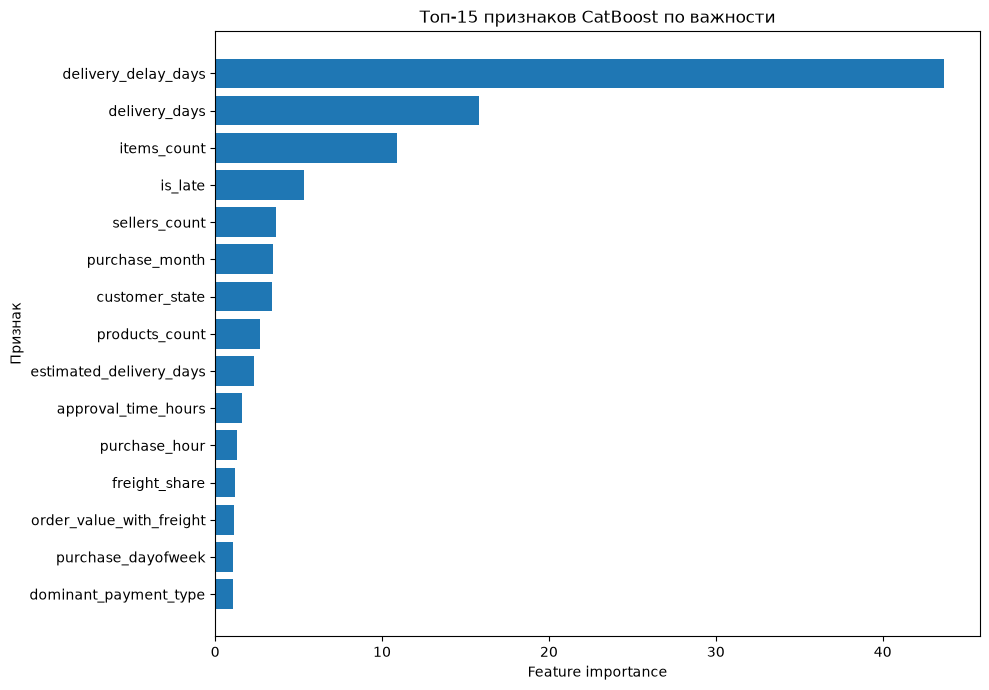

In [41]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(15).sort_values(
    "importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["feature"],
    top_features["importance"],
)

plt.title("Топ-15 признаков CatBoost по важности")
plt.xlabel("Feature importance")
plt.ylabel("Признак")
plt.tight_layout()
plt.show()

## Важность признаков CatBoost

Для первичной интерпретации модели используется встроенная важность признаков CatBoost — `PredictionValuesChange`.

Метрика показывает, насколько в среднем меняются прогнозы модели при использовании конкретного признака. Чем выше значение, тем активнее модель использует признак при принятии решений.

При этом feature importance:

- не показывает направление влияния;
- не доказывает причинно-следственную связь;
- может распределяться между коррелирующими признаками.

Поэтому после общего ранжирования наиболее важных факторов будет проведён SHAP-анализ.

## Интерпретация важности признаков

Главным фактором прогнозирования негативного отзыва стала задержка доставки относительно обещанной даты. На `delivery_delay_days` приходится около 43,6% общей встроенной важности CatBoost.

Другими значимыми признаками оказались:

- фактическая продолжительность доставки;
- количество товарных позиций в заказе;
- факт опоздания;
- количество продавцов в заказе.

Это указывает на то, что риск негативного клиентского опыта связан прежде всего с логистикой и сложностью исполнения заказа.

Заказы с несколькими товарами или продавцами могут быть сложнее с операционной точки зрения: отдельные позиции могут отправляться в разное время, а вероятность задержек или несогласованности доставки увеличивается.

При этом несколько наиболее важных доставочных признаков математически связаны между собой. Например, `is_late` определяется на основе `delivery_delay_days`, а сама задержка зависит от фактической и ожидаемой дат доставки. Поэтому встроенную важность нельзя интерпретировать как независимый причинный вклад каждого признака.

Feature importance показывает, какие признаки активно использует модель, но не показывает, повышает или снижает конкретное значение вероятность негативного отзыва. Для определения направления влияния далее используется SHAP-анализ.

In [42]:
from catboost import Pool
import shap

In [43]:
shap_sample = X_test_cb.sample(
    n=min(2000, len(X_test_cb)),
    random_state=42,
)

shap_pool = Pool(
    shap_sample,
    cat_features=categorical_features,
)

shap_values_raw = final_catboost_model.get_feature_importance(
    shap_pool,
    type="ShapValues",
)

shap_values = shap_values_raw[:, :-1]
base_values = shap_values_raw[:, -1]

print("SHAP matrix:", shap_values.shape)
print("Количество признаков:", len(feature_columns))

SHAP matrix: (2000, 19)
Количество признаков: 19


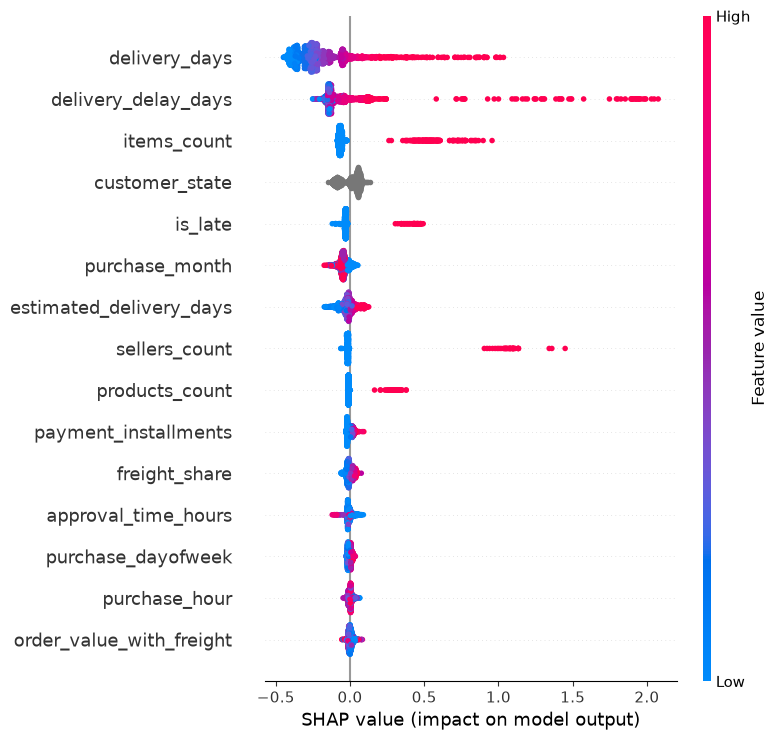

In [44]:
shap.summary_plot(
    shap_values,
    shap_sample,
    feature_names=feature_columns,
    max_display=15,
)

## SHAP-интерпретация модели

SHAP-анализ подтверждает, что основными факторами прогнозируемого риска негативного отзыва являются характеристики доставки и сложность исполнения заказа.

Высокие значения фактической продолжительности доставки смещают прогноз модели в сторону негативного отзыва. Аналогичная зависимость наблюдается для задержки относительно обещанной даты: чем сильнее заказ опоздал, тем выше модельный риск плохого клиентского опыта.

Флаг просроченной доставки также имеет выраженный положительный вклад в прогноз. Это подтверждает, что для клиента важна не только абсолютная длительность ожидания, но и выполнение обещанного срока.

Большое количество товарных позиций, уникальных товаров и продавцов в заказе также повышает прогнозируемый риск. Возможное бизнес-объяснение состоит в том, что сложные заказы труднее синхронизировать: позиции могут отправляться отдельно, иметь разные сроки доставки или создавать больше возможностей для операционной ошибки.

Финансовые характеристики заказа, тип оплаты и время покупки оказались существенно менее значимыми по сравнению с логистическими факторами.

Признак месяца покупки показывает, что модель учитывает временные изменения качества клиентского опыта. Такой признак может улучшать качество на исторических данных, но требует осторожности: временные закономерности могут измениться после внедрения модели.

SHAP-значения отражают вклад признака в конкретный прогноз модели, но не доказывают причинно-следственную связь. Кроме того, эффекты коррелирующих доставочных признаков могут распределяться между `delivery_days`, `delivery_delay_days`, `estimated_delivery_days` и `is_late`.

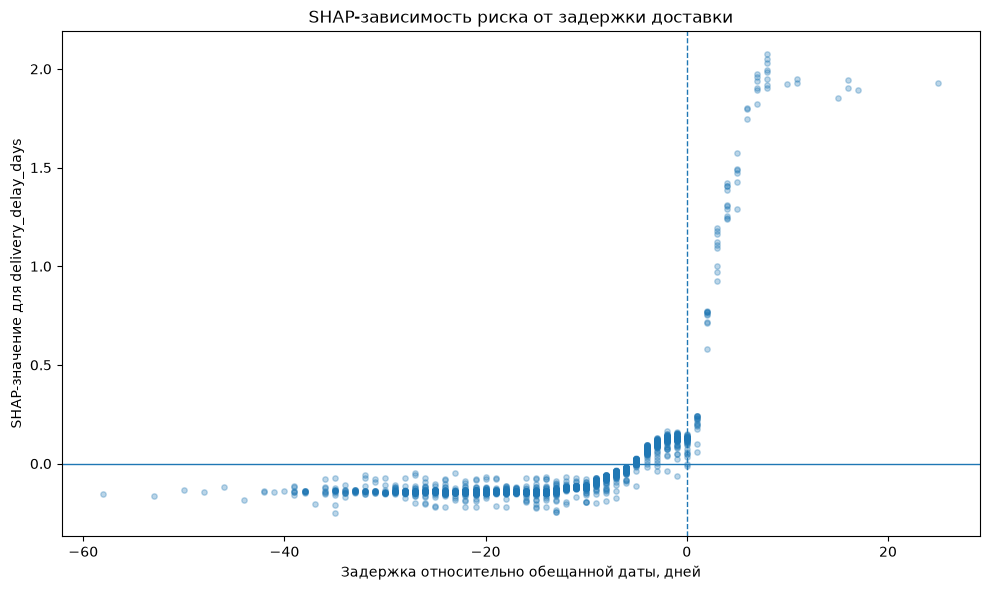

In [45]:
delay_feature_index = feature_columns.index(
    "delivery_delay_days"
)

plt.figure(figsize=(10, 6))

plt.scatter(
    shap_sample["delivery_delay_days"],
    shap_values[:, delay_feature_index],
    alpha=0.3,
    s=15,
)

plt.axhline(
    0,
    linewidth=1,
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=1,
)

plt.title(
    "SHAP-зависимость риска от задержки доставки"
)
plt.xlabel(
    "Задержка относительно обещанной даты, дней"
)
plt.ylabel(
    "SHAP-значение для delivery_delay_days"
)

plt.tight_layout()
plt.show()

## Нелинейное влияние задержки доставки

SHAP dependence plot показывает выраженную нелинейную связь между задержкой доставки и прогнозируемым риском негативного отзыва.

Если заказ доставлен раньше обещанной даты, вклад `delivery_delay_days` обычно отрицательный: признак снижает прогноз модели.

При доставке около обещанной даты влияние приближается к нейтральному. После начала опоздания вклад становится положительным, а примерно при задержке на 3–5 дней наблюдается особенно резкий рост модельного риска.

Для бизнеса это означает, что важно не только контролировать сам факт просрочки. Заказы, задержанные на несколько дней и более, могут требовать отдельной приоритизации: проактивного уведомления клиента, уточнения статуса доставки или компенсационного сценария.

Однако SHAP отражает закономерности прогнозной модели, а не причинно-следственный эффект. Кроме того, задержка связана с продолжительностью доставки и другими логистическими признаками. Поэтому предполагаемую границу риска необходимо дополнительно проверить на фактической доле негативных отзывов.

In [46]:
delay_bins = [
    -np.inf,
    -14,
    -7,
    -1,
    0,
    2,
    5,
    10,
    np.inf,
]

delay_labels = [
    "раньше на 14+ дней",
    "раньше на 7–13 дней",
    "раньше на 1–6 дней",
    "в обещанный день",
    "задержка 1–2 дня",
    "задержка 3–5 дней",
    "задержка 6–10 дней",
    "задержка более 10 дней",
]

delay_analysis = (
    test_data
    .dropna(subset=["delivery_delay_days"])
    .assign(
        delay_group=lambda df: pd.cut(
            df["delivery_delay_days"],
            bins=delay_bins,
            labels=delay_labels,
            include_lowest=True,
        )
    )
    .groupby(
        "delay_group",
        observed=False,
    )
    .agg(
        orders=("order_id", "size"),
        bad_reviews=("bad_review", "sum"),
        bad_review_rate=("bad_review", "mean"),
        median_delay_days=("delivery_delay_days", "median"),
    )
    .reset_index()
)

delay_analysis["orders_share"] = (
    delay_analysis["orders"]
    / delay_analysis["orders"].sum()
)

delay_analysis[
    [
        "delay_group",
        "orders",
        "orders_share",
        "bad_reviews",
        "bad_review_rate",
        "median_delay_days",
    ]
].round(4)

,delay_group,orders,orders_share,bad_reviews,bad_review_rate,median_delay_days
0,раньше на 14+ дней,8099,0.4373,1241,0.1532,-20.0
1,раньше на 7–13 дней,5743,0.3101,870,0.1515,-10.0
2,раньше на 1–6 дней,3678,0.1986,523,0.1422,-4.0
3,в обещанный день,344,0.0186,57,0.1657,0.0
4,задержка 1–2 дня,219,0.0118,64,0.2922,1.0
5,задержка 3–5 дней,187,0.0101,118,0.6310,4.0
6,задержка 6–10 дней,147,0.0079,118,0.8027,7.0
7,задержка более 10 дней,103,0.0056,80,0.7767,17.0


## Фактическая доля негативных отзывов по задержке доставки

Анализ независимого тестового периода подтверждает закономерность, выявленную моделью и SHAP-анализом.

Для заказов, доставленных раньше обещанной даты, доля негативных отзывов находится примерно на уровне 14–15%. При доставке в обещанный день она составляет 16,6%.

Даже небольшая задержка заметно ухудшает клиентский опыт:

- задержка на 1–2 дня — 29,2% негативных отзывов;
- задержка на 3–5 дней — 63,1%;
- задержка на 6–10 дней — 80,3%;
- задержка более чем на 10 дней — 77,7%.

Таким образом, особенно критичной выглядит граница примерно в 3 дня просрочки. После неё большинство заказов в тестовом периоде получило негативную оценку.

Для бизнеса это может служить основанием для многоуровневого операционного сценария:

- при прогнозируемой задержке на 1–2 дня — своевременно уведомить клиента;
- при задержке от 3 дней — приоритизировать заказ для проактивной поддержки;
- при длительной задержке — рассмотреть компенсацию или дополнительный контроль доставки.

При этом результат является наблюдаемой ассоциацией, а не доказанным причинным эффектом. В группах с длительной задержкой относительно мало заказов, поэтому точные значения необходимо интерпретировать осторожно.

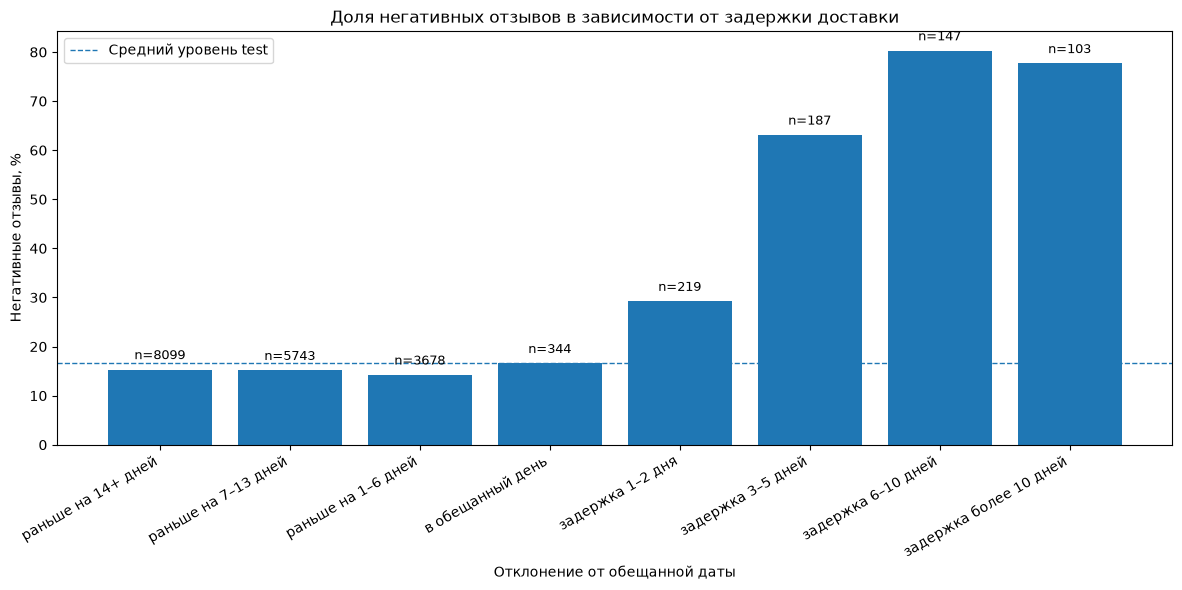

In [47]:
delay_plot = delay_analysis.copy()

delay_plot["bad_review_rate_pct"] = (
    delay_plot["bad_review_rate"] * 100
)

plt.figure(figsize=(12, 6))

bars = plt.bar(
    delay_plot["delay_group"],
    delay_plot["bad_review_rate_pct"],
)

plt.axhline(
    y=y_test.mean() * 100,
    linestyle="--",
    linewidth=1,
    label="Средний уровень test",
)

for bar, orders in zip(bars, delay_plot["orders"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1.5,
        f"n={orders}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.title(
    "Доля негативных отзывов в зависимости от задержки доставки"
)
plt.xlabel("Отклонение от обещанной даты")
plt.ylabel("Негативные отзывы, %")
plt.xticks(rotation=30, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

## Ограничения модели

При интерпретации результатов необходимо учитывать несколько ограничений.

1. **Модель работает после завершения доставки.**  
   В ней используются фактическая продолжительность доставки и задержка относительно обещанной даты. Поэтому текущая версия подходит для выявления проблемных заказов после доставки, анализа факторов плохого опыта и приоритизации последующей работы с клиентами. Она не может использоваться для прогноза сразу в момент оформления заказа.

2. **Выборка включает только заказы с отзывами.**  
   Для заказов без оценки целевая переменная неизвестна. Клиенты, которые оставляют отзывы, могут отличаться от остальных покупателей, поэтому возможен selection bias.

3. **Есть временное изменение распределения данных.**  
   Доля негативных отзывов снизилась с 22,13% в train до 16,58% в test. Из-за temporal drift качество модели и доля заказов, превышающих фиксированный порог, меняются между периодами.

4. **Порог требует регулярной перекалибровки.**  
   Порог 0,30 был выбран на validation-периоде, однако на test он сформировал меньшую группу риска. В реальной системе порог необходимо пересматривать либо использовать ранжирование фиксированной доли заказов, например top 10%.

5. **Доставочные признаки коррелируют между собой.**  
   `delivery_days`, `delivery_delay_days`, `estimated_delivery_days` и `is_late` описывают связанные аспекты доставки. Поэтому их важности нельзя интерпретировать как независимые эффекты.

6. **SHAP и feature importance не доказывают причинность.**  
   Модель выявляет статистические закономерности. Рост негативных отзывов при задержке доставки является сильной ассоциацией, но не результатом контролируемого эксперимента.

7. **Данные исторические и относятся к конкретному маркетплейсу.**  
   Датасет охватывает бразильский рынок Olist за 2016–2018 годы. Перед использованием модели в другом периоде или бизнесе потребуется повторное обучение и проверка качества.

8. **Набор признаков ограничен доступными данными.**  
   В датасете отсутствуют обращения в поддержку, причины возвратов, отмены отдельных позиций, история коммуникаций, фактические логистические события и другие признаки, которые могли бы улучшить качество модели.

In [48]:
from pathlib import Path

reports_dir = Path("../reports")
reports_dir.mkdir(exist_ok=True)

model_results = (
    final_model_comparison
    .reset_index()
    .rename(columns={"index": "model"})
)

model_results["threshold"] = [
    selected_threshold,
    selected_catboost_threshold,
]

model_results["accuracy"] = [
    final_logistic_metrics["accuracy"],
    final_catboost_metrics["accuracy"],
]

model_results["predicted_positive_orders"] = [
    int(final_logistic_metrics["predicted_positive_orders"]),
    int(final_catboost_metrics["predicted_positive_orders"]),
]

model_results["test_orders"] = len(y_test)
model_results["test_bad_review_rate"] = y_test.mean()

model_results = model_results[
    [
        "model",
        "threshold",
        "roc_auc",
        "pr_auc",
        "lift_at_10",
        "top_10_bad_review_rate",
        "accuracy",
        "precision",
        "recall",
        "f1",
        "predicted_positive_share",
        "predicted_positive_orders",
        "test_orders",
        "test_bad_review_rate",
    ]
]

model_results.to_csv(
    reports_dir / "model_results.csv",
    index=False,
)

model_results.round(4)

,model,threshold,roc_auc,pr_auc,lift_at_10,top_10_bad_review_rate,accuracy,precision,recall,f1,predicted_positive_share,predicted_positive_orders,test_orders,test_bad_review_rate
0,Logistic Regression,0.3,0.6491,0.3439,2.6539,0.4401,0.8373,0.5242,0.2044,0.2941,0.0647,1198,18526,0.1658
1,CatBoost,0.3,0.6499,0.3640,2.6832,0.4449,0.8419,0.5657,0.2005,0.2961,0.0588,1089,18526,0.1658


# Итоги ML-анализа

В рамках анализа была построена модель риска негативного клиентского опыта для доставленных заказов Olist.

Целевая переменная определялась как:

- `bad_review = 1`, если `review_score <= 3`;
- `bad_review = 0`, если `review_score >= 4`.

Для предотвращения утечки данных из признаков были исключены оценка отзыва, даты создания и ответа на отзыв, текст комментария и другие характеристики, возникающие после появления целевой переменной.

Выборка была разделена по времени:

- обучение — заказы до июня 2018 года;
- тестирование — заказы за июнь–август 2018 года.

Такое разделение имитирует применение модели к будущим заказам и позволяет оценить её устойчивость к изменению распределения данных.

## Результаты моделей

Были сравнены две модели:

- Logistic Regression как интерпретируемый baseline;
- CatBoost как нелинейная модель, способная учитывать взаимодействия между числовыми и категориальными признаками.

На независимом тестовом периоде CatBoost получил:

- ROC-AUC — 0,650;
- PR-AUC — 0,364;
- lift@10% — 2,68;
- precision — 56,57%;
- recall — 20,05%;
- F1-score — 0,296.

Среди 10% заказов с максимальным прогнозируемым риском доля негативных отзывов составила около 44,5%, тогда как средний уровень тестовой выборки был равен 16,6%.

CatBoost лишь умеренно превзошёл Logistic Regression, но показал более высокий PR-AUC и precision при меньшем количестве ложных срабатываний. Поэтому он был выбран как основная модель для сценария с ограниченным ресурсом клиентской поддержки.

## Основные факторы риска

Feature importance и SHAP-анализ показали, что модель в первую очередь использует:

- задержку относительно обещанной даты;
- фактическую продолжительность доставки;
- количество товарных позиций;
- количество продавцов;
- сложность состава заказа.

На тестовом периоде фактическая доля негативных отзывов составила:

- 29,2% при задержке на 1–2 дня;
- 63,1% при задержке на 3–5 дней;
- 80,3% при задержке на 6–10 дней.

Это указывает на резкое ухудшение клиентского опыта после нескольких дней просрочки.

## Бизнес-применение

Модель может использоваться как инструмент приоритизации:

- ранжировать доставленные заказы по риску негативного отзыва;
- выделять ограниченный top-сегмент для проактивной поддержки;
- выявлять проблемные логистические сценарии;
- контролировать сложные заказы с несколькими товарами или продавцами;
- формировать операционные правила реагирования на задержки.

Текущая модель работает после завершения доставки. Следующей итерацией проекта может стать модель раннего предупреждения, использующая только признаки, доступные в момент оформления или во время исполнения заказа.

## Главный вывод

Качество клиентского опыта в данных Olist связано прежде всего с выполнением логистического обещания. Даже небольшое опоздание повышает риск негативного отзыва, а задержка на три дня и более становится критическим операционным сигналом.

При этом умеренные метрики модели показывают, что улучшение алгоритма само по себе недостаточно. Для более точного прогнозирования потребовались бы дополнительные данные об этапах доставки, обращениях в поддержку, коммуникациях с клиентом и проблемах отдельных товарных позиций.